## Notebook 02 - Stage 1: Hierarchical Bayesian Weibull
### Depreciation Curve Estimation with Partial Pooling
Fits `RVR(t) = exp(-(t/λ)^k)` per segment, with brand-level partial pooling via PyMC.

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [13]:
# Imports libraries
import cloudpickle
import warnings
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, "..")

from src.stage1_hierachical_model import build_segment_indices, fit_hierarchical_weibull, extract_posterior_features
from src.plot_function import plot_weibull_curves

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 30)
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_parquet(
    "../data/processed/car_data.parquet",
    engine = "pyarrow"
)

# Time-based train/test split
CUTOFF = "2020-01-01"
train = df[df["sold_date"] < CUTOFF].copy()
test = df[df["sold_date"] >= CUTOFF].copy()
print(f"Train: {len(train):,} | Test: {len(test):,}")

Train: 18,738 | Test: 7,366


In [4]:
# Build segment indices from training data
idx = build_segment_indices(train, segment_col = "segment", brand_col = "brand_tier")
print(f"{"Segments":<{10}}: {idx['n_seg']}")
print(f"{"Brands":<{10}}: {idx['n_brand']}")
print("Segment names:", idx["seg_names"])

Segments  : 8
Brands    : 3
Segment names: ['luxury_Benzene', 'luxury_Diesel', 'pickup_Benzene', 'pickup_Diesel', 'pickup_NGV', 'standard_Benzene', 'standard_Diesel', 'standard_NGV']


In [5]:
# Fit Hierarchical Bayesian Weibull (Stage 1)
# Note: draws/tune can be reduced for quick testing
bayes_result = fit_hierarchical_weibull(
    train,
    idx,
    draws = 1000,
    tune = 1000,
    chains = 4
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_log_lam, sigma_log_lam, mu_log_k, sigma_log_k, log_lam_seg, log_k_seg, kappa]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 906 seconds.


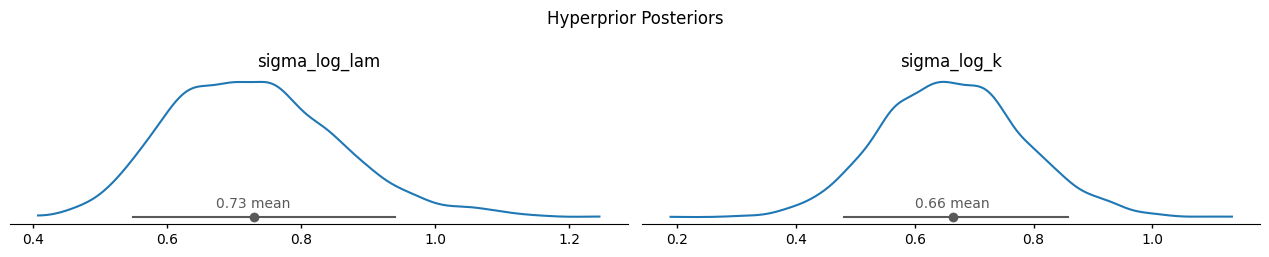

In [6]:
# MCMC diagnostics
az.plot_dist(bayes_result["trace"], var_names = ["sigma_log_lam", "sigma_log_k"])
plt.suptitle("Hyperprior Posteriors")
plt.tight_layout()
plt.show()

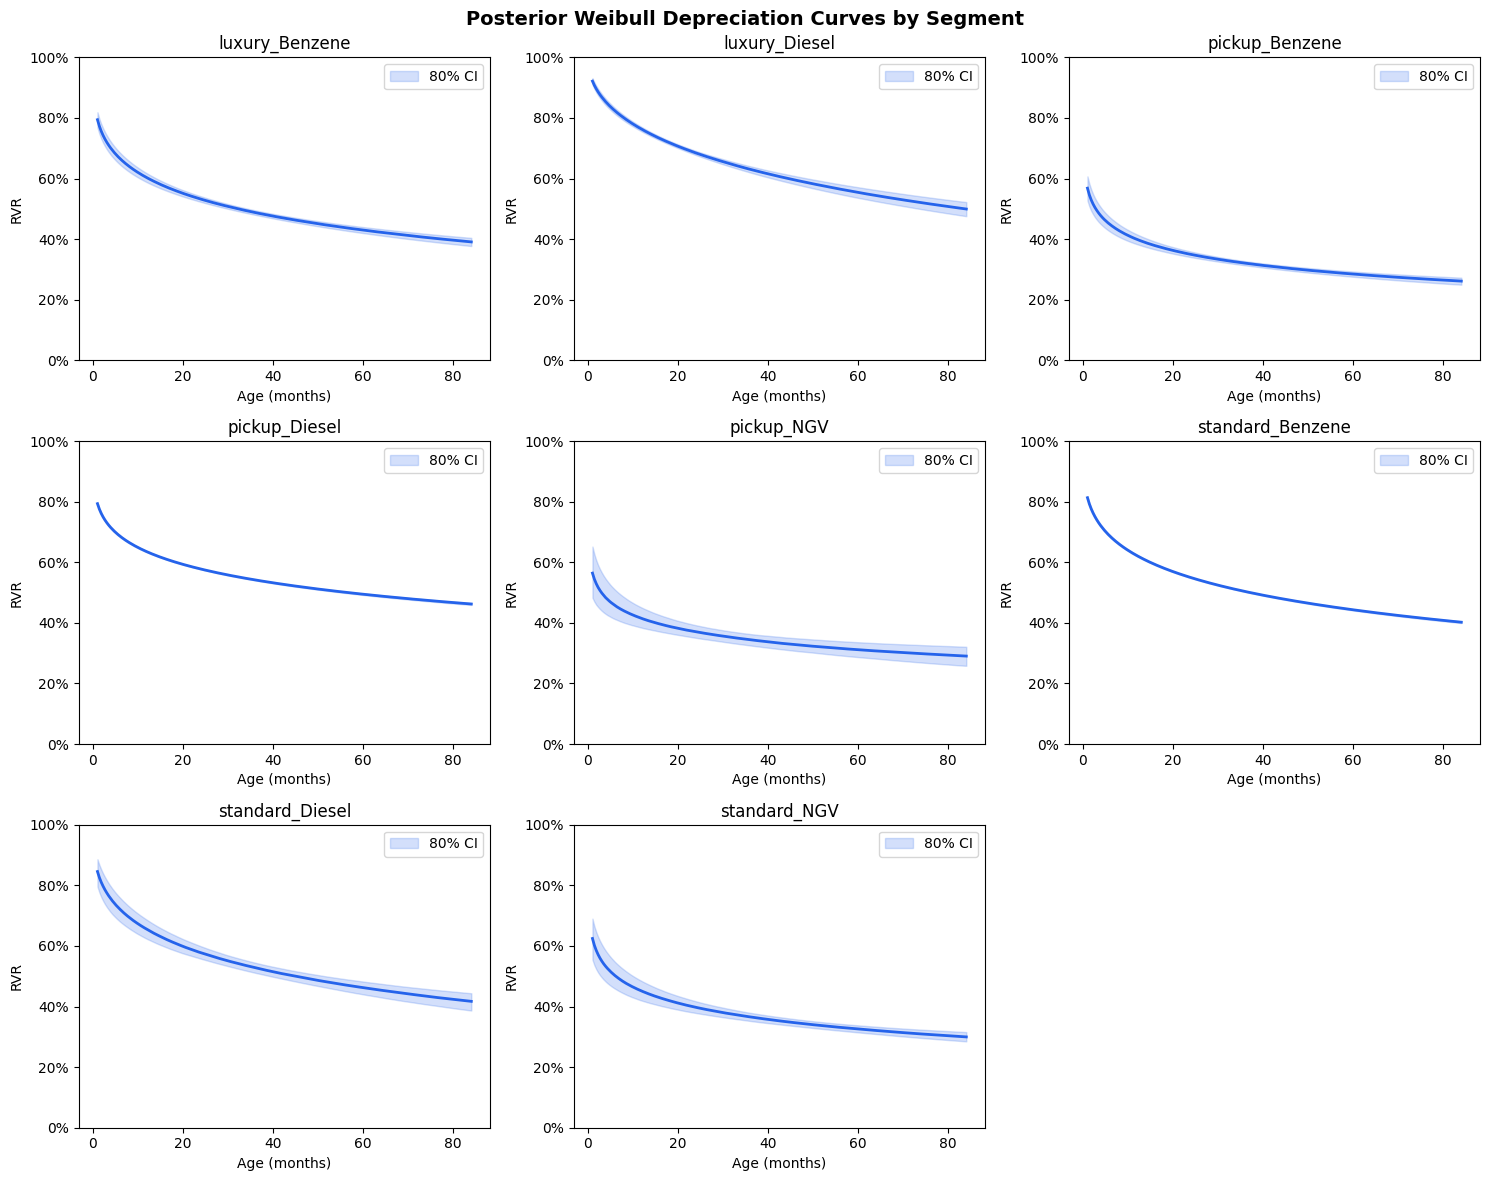

In [7]:
# Plot depreciation curves
plot_weibull_curves(bayes_result, t_max = 84)

In [8]:
# Extract posterior features for train and test
train = extract_posterior_features(train, bayes_result)
test = extract_posterior_features(test,  bayes_result)
print("Stage 1 Model: Features added")
print(train[["theoretical_rvr","theoretical_rvr_std","curve_uncertainty","rvr_residual"]].describe())

Stage 1 Model: Features added
       theoretical_rvr  theoretical_rvr_std  curve_uncertainty  rvr_residual
count        18738.000            18738.000          18738.000     18738.000
mean             0.550                0.002              0.005         0.002
std              0.085                0.002              0.005         0.100
min              0.257                0.001              0.003        -0.575
25%              0.491                0.001              0.003        -0.036
50%              0.552                0.001              0.004         0.018
75%              0.614                0.002              0.004         0.065
max              0.870                0.040              0.099         0.391


In [14]:
# Export Stage 1 Model
with open("../model/stage1_bayes_model.pkl", "wb") as f:
    cloudpickle.dump(bayes_result, f)

# Export data
train.to_parquet(
    "../data/processed/train_data.parquet",
    engine = "pyarrow"
)

test.to_parquet(
    "../data/processed/test_data.parquet",
    engine = "pyarrow"
)